In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np
import json


import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": "CMU Serif",
        "text.usetex": True,
        "text.latex.preamble": r"\usepackage{amsmath}",
        "font.size": 12,
        "font.weight": "normal",
        "figure.titlesize": "medium",
        "xtick.color": "black",
        "ytick.color": "black",
        "axes.labelcolor": "black",
        "text.color": "black",
        "savefig.dpi": 300,
        "figure.dpi": 150,
        "savefig.bbox": "tight",
    }
)

In [6]:
import pandas as pd
import re

def parse_data_with_markers(data):
    lines = data.strip().split('\n')
    headers = lines[0].replace('|', '').split()
    processed_data = []

    for line in lines[2:]:
        values = re.split(r'\s+', line.strip())
        # print(values[2:3])

        # Adjust according to markers 'H' or '*'
        if values[0] == 'H':
            # Insert None for Obj, Depth, IntInf
            values = [values[0], values[1], values[2], None, None, None] + values[3:]
        elif values[0] == '*':
            # Insert None for Obj and for subsequent indices to match headers
            values = [values[0], values[1], values[2], None] + values[3:]
            values.insert(5, None)  # Adding None for IntInf based on the new index position
        elif any(keyword in values[2:3] for keyword in ['infeasible', 'cutoff', 'postponed']):
            values = [values[0], values[1], values[2], values[3], None,] + values[4:]

        # Remove the marker now that adjustments are made
        if values[0] in ['H', '*']:
            values.pop(0)

        # Ensure each row has the correct number of columns
        while len(values) < len(headers):
            values.append(None)  # Padding with None

        processed_data.append(values)
        
        processed_df = pd.DataFrame(processed_data, columns=headers)
        
        processed_df['Time'] = processed_df['Time'].str.rstrip('s')
        processed_df['Time'] = processed_df['Time'].astype(int)

    return processed_df



In [7]:
# Open and read the file as plain text
with open('log_output_10_scenarios_5deltas_true_overlap_true_capacity.json', 'r') as file:
    text = file.read()

# Define the start and end markers for the data extraction
start_marker = "Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time"
end_marker = "Cutting planes:"

# Find the start and end index of the data to be extracted
start_index = text.find(start_marker)
end_index = text.find(end_marker, start_index)

# Extract the data between these indices
extracted_data = text[start_index:end_index].strip()

# Applying the modified parser
df_with_markers = parse_data_with_markers(extracted_data)
df_with_markers



,Expl,Unexpl,Obj,Depth,IntInf,Incumbent,BestBd,Gap,It/Node,Time
0,0,0,6.6789e+10,0,118,-,6.6789e+10,-,-,6
1,0,0,6.6816e+10,0,158,-,6.6816e+10,-,-,15
2,0,0,6.6822e+10,0,152,-,6.6822e+10,-,-,16
3,0,0,6.6822e+10,0,152,-,6.6822e+10,-,-,16
4,0,0,6.6836e+10,0,156,-,6.6836e+10,-,-,17
...,...,...,...,...,...,...,...,...,...,...
62,1445,340,cutoff,8,None,6.7263e+10,6.7225e+10,0.06%,335,157
63,1486,311,cutoff,15,None,6.7263e+10,6.7236e+10,0.04%,344,160
64,1530,305,cutoff,15,None,6.7263e+10,6.7250e+10,0.02%,358,168
65,1571,305,None,26,None,6.726239e+10,6.7252e+10,0.02%,380,168


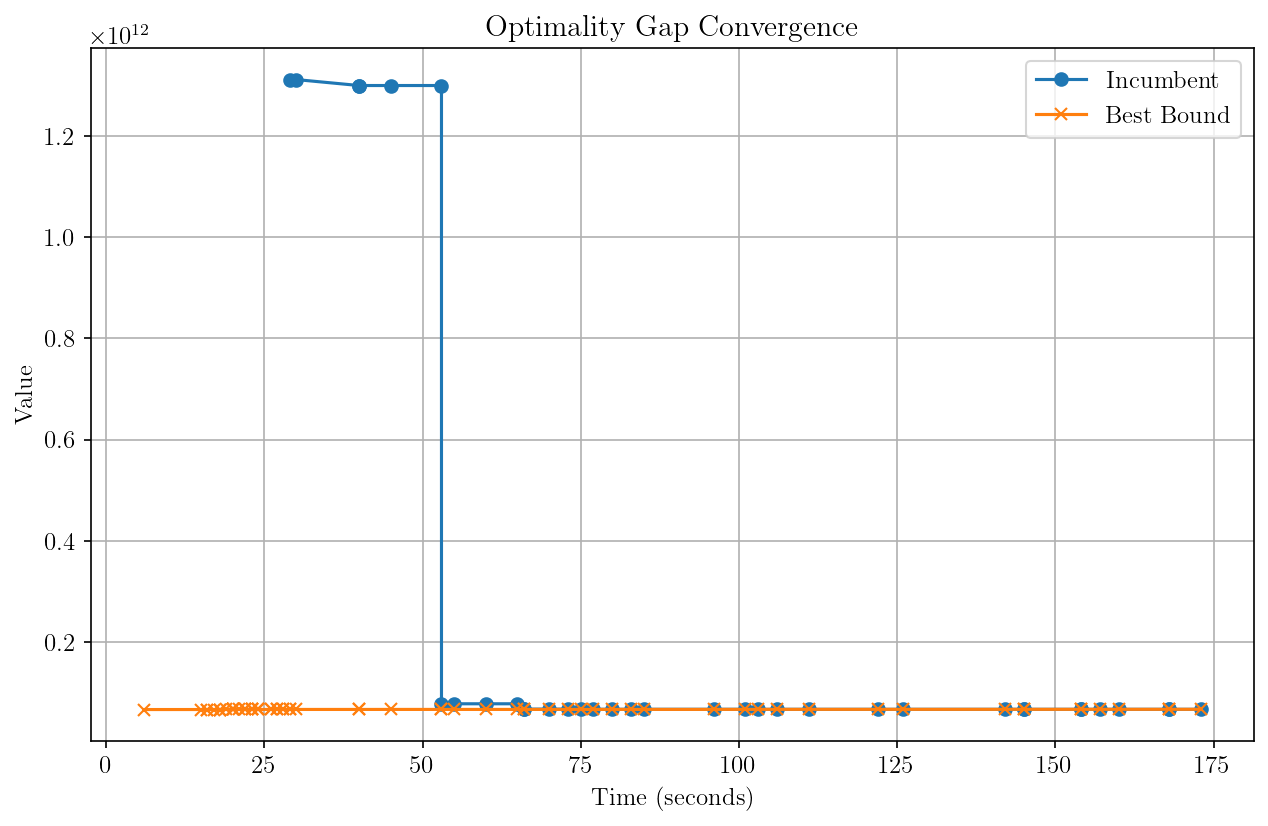

In [8]:
# Convert values to floats if they are not already
df = df_with_markers
df['Incumbent'] = pd.to_numeric(df['Incumbent'], errors='coerce')
df['BestBd'] = pd.to_numeric(df['BestBd'], errors='coerce')

# Plotting Incumbent and BestBd versus Time
plt.figure(figsize=(10, 6))
plt.plot(df['Time'], df['Incumbent'], label='Incumbent', marker='o')
plt.plot(df['Time'], df['BestBd'], label='Best Bound', marker='x')

# Coordinates for the last points of each line
x_last_time = df['Time'].iloc[-1]
incumbent_last_value = df['Incumbent'].iloc[-1]
bestbd_last_value = df['BestBd'].iloc[-1]
final_gap = df['Gap'].iloc[-1]  # This should already be a string if it's a percentage
mid_gap = df_with_markers['Gap'].iloc[3]

# plt.annotate(f'\% Gap: {final_gap}', xy=(x_last_time-5, bestbd_last_value + (bestbd_last_value/100)),
#         textcoords='data',ha='center', va='center', fontsize=10, color = 'green')

# plt.annotate(f'\% Gap: {mid_gap}', xy=(df['Time'].iloc[32], bestbd_last_value + (bestbd_last_value/30)),
#         textcoords='data',ha='center', va='center', fontsize=10, color = 'green')

# Adding labels, title, and grid
plt.xlabel('Time (seconds)')
plt.ylabel('Value')
plt.title('Optimality Gap Convergence')
plt.legend()
plt.grid(True)
plt.savefig('two_stage_10_scenario_5_delta.pdf', bbox_inches='tight', pad_inches=0.1, dpi=600)
plt.show()


